<a href="https://colab.research.google.com/github/hvsya/AI-Project_PlantVillage/blob/main/DataPreparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
import shutil
import random
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

In [2]:
API_KEY = "56176072-1983ee0cdada61ad276cb2567"

In [3]:
RAW_DIR = "plantvillage_raw"
CLEAN_DIR = "plantvillage_standardized"
OUTPUT_DIR = "final_plantvillage_dataset"
TARGET_SIZE = (224, 224)

In [4]:
plant_classes = {
    "Apple_scab": "apple leaf scab disease",
    "Apple_Black_rot": "apple black rot plant",
    "Apple_Cedar_apple_rust": "apple cedar rust leaf",
    "Apple_healthy": "healthy apple leaf",
    "Blueberry_healthy": "blueberry bush leaf",
    "Corn_Common_rust": "corn rust plant disease",
    "Grape_Black_rot": "grape black rot disease",
    "Peach_Bacterial_spot": "peach bacterial spot leaf",
    "Tomato_healthy": "healthy tomato leaf",
    "Tomato_Late_blight": "tomato late blight leaf"
}

os.makedirs(RAW_DIR, exist_ok=True)

a. Collecting data

In [6]:
print("\n--- Starting Web Crawler Pipeline ---")

for sub_name, search_term in plant_classes.items():
    print(f"\nCrawling Class: '{sub_name}' using query: '{search_term}'...")
    target_folder = os.path.join(RAW_DIR, sub_name)
    os.makedirs(target_folder, exist_ok=True)

    downloaded = 0
    page = 1
    per_page = 200  # Max results allowed per API request payload

    while downloaded < 1000:
        # Construct URL safely changing spaces into web-safe syntax '+'
        url = f"https://pixabay.com/api/?key={API_KEY}&q={search_term.replace(' ', '+')}&image_type=photo&per_page={per_page}&page={page}&safesearch=true"

        try:
            response = requests.get(url, timeout=15)
            data = response.json()
            hits = data.get('hits', [])
        except Exception as e:
            print(f"\n[Warning] Connection issue encountered: {e}. Skipping category.")
            break

        # Break loop if the crawler runs out of public search results
        if not hits:
            print(f"\n[Notice] No more open-source pictures found for query: '{search_term}'")
            break

        for hit in hits:
            if downloaded >= 1000:
                break
            try:
                img_url = hit['webformatURL']
                img_data = requests.get(img_url, timeout=10).content
                file_path = os.path.join(target_folder, f"{sub_name}_{downloaded:04d}.jpg")

                with open(file_path, 'wb') as f:
                    f.write(img_data)

                downloaded += 1
                print(f"  Progress: Saved {downloaded}/{1000} images", end="\r")
            except Exception:
                continue  # Silently skip broken individual download streams

        page += 1
        time.sleep(1.2)  # Polite pause to prevent API rate limit bans

    print(f"\nFinished '{sub_name}': Cached {downloaded} raw images successfully.")


--- Starting Web Crawler Pipeline ---

Crawling Class: 'Apple_scab' using query: 'apple leaf scab disease'...

[Warning] Connection issue encountered: Expecting value: line 1 column 2 (char 1). Skipping category.

Finished 'Apple_scab': Cached 600 raw images successfully.

Crawling Class: 'Apple_Black_rot' using query: 'apple black rot plant'...

[Warning] Connection issue encountered: Expecting value: line 1 column 2 (char 1). Skipping category.

Finished 'Apple_Black_rot': Cached 600 raw images successfully.

Crawling Class: 'Apple_Cedar_apple_rust' using query: 'apple cedar rust leaf'...

[Warning] Connection issue encountered: Expecting value: line 1 column 2 (char 1). Skipping category.

Finished 'Apple_Cedar_apple_rust': Cached 600 raw images successfully.

Crawling Class: 'Apple_healthy' using query: 'healthy apple leaf'...

[Warning] Connection issue encountered: Expecting value: line 1 column 2 (char 1). Skipping category.

Finished 'Apple_healthy': Cached 600 raw images succ

b. Cleaning data

In [7]:
def clean_corrupted_files(root_folder):
    print("\n--- Sanitizing Dataset (Removing Corrupted Files) ---")
    removed_count = 0
    for subdir, _, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                path = os.path.join(subdir, file)
                try:
                    with Image.open(path) as img:
                        img.verify()  # Evaluates structural validity of headers
                except Exception:
                    os.remove(path)
                    removed_count += 1
    print(f"Sanitization complete. Deleted {removed_count} unreadable/corrupt files.")

clean_corrupted_files(RAW_DIR)


--- Sanitizing Dataset (Removing Corrupted Files) ---
Sanitization complete. Deleted 0 unreadable/corrupt files.


c. Standardize data

In [8]:
print("\n--- Standardizing Images to 224x224 RGB Format ---")
os.makedirs(CLEAN_DIR, exist_ok=True)

for sub_name in os.listdir(RAW_DIR):
    src_path = os.path.join(RAW_DIR, sub_name)
    if not os.path.isdir(src_path):
        continue
    dst_path = os.path.join(CLEAN_DIR, sub_name)
    os.makedirs(dst_path, exist_ok=True)

    for img_file in os.listdir(src_path):
        img_path = os.path.join(src_path, img_file)
        try:
            with Image.open(img_path) as img:
                # Force every pixel array to standard 3-channel RGB (Removes transparency alpha layers)
                img = img.convert("RGB")
                img = img.resize(TARGET_SIZE)
                out_name = os.path.splitext(img_file)[0] + ".jpg"
                img.save(os.path.join(dst_path, out_name), "JPEG", quality=90)
        except Exception:
            continue

print("Image size and channel standardization process finished.")


--- Standardizing Images to 224x224 RGB Format ---
Image size and channel standardization process finished.


d. Create dataset

In [9]:
print("\n--- Splitting Dataset into Train, Validation, and Test Sets ---")
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

classes = [d for d in os.listdir(CLEAN_DIR) if os.path.isdir(os.path.join(CLEAN_DIR, d))]
train_ratio, val_ratio = 0.70, 0.15  # Remaining 15% naturally serves as test set

for cls in classes:
    class_path = os.path.join(CLEAN_DIR, cls)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    random.seed(42)  # Keeps data allocations predictable across runs
    random.shuffle(images)

    train_end = int(len(images) * train_ratio)
    val_end = int(len(images) * (train_ratio + val_ratio))

    splits = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }

    for split_name, img_list in splits.items():
        target_dir = os.path.join(OUTPUT_DIR, split_name, cls)
        os.makedirs(target_dir, exist_ok=True)
        for img in img_list:
            shutil.copy2(os.path.join(class_path, img), os.path.join(target_dir, img))

    print(f"  {cls}: Train={len(splits['train'])}, Val={len(splits['val'])}, Test={len(splits['test'])}")

print(f"Split complete. Final organized files are saved under: '{OUTPUT_DIR}/'")


--- Splitting Dataset into Train, Validation, and Test Sets ---
  Apple_Black_rot: Train=420, Val=90, Test=90
  Apple_healthy: Train=420, Val=90, Test=90
  Tomato_healthy: Train=420, Val=90, Test=90
  Grape_Black_rot: Train=420, Val=90, Test=90
  Blueberry_healthy: Train=420, Val=90, Test=90
  Peach_Bacterial_spot: Train=420, Val=90, Test=90
  Tomato_Late_blight: Train=420, Val=90, Test=90
  Corn_Common_rust: Train=420, Val=90, Test=90
  Apple_scab: Train=420, Val=90, Test=90
  Apple_Cedar_apple_rust: Train=420, Val=90, Test=90
Split complete. Final organized files are saved under: 'final_plantvillage_dataset/'


In [10]:
print("\n--- Creating TensorFlow Datasets ---")

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(OUTPUT_DIR, 'train'),
    image_size=TARGET_SIZE,
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(OUTPUT_DIR, 'val'),
    image_size=TARGET_SIZE,
    batch_size=32,
    label_mode='categorical'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(OUTPUT_DIR, 'test'),
    image_size=TARGET_SIZE,
    batch_size=32,
    label_mode='categorical'
)

print("\n✅ Cleaned custom web-crawler datasets loaded into TensorFlow successfully.")
print("Registered Pipeline Class Labels:", train_ds.class_names)


--- Creating TensorFlow Datasets ---
Found 4200 files belonging to 10 classes.
Found 900 files belonging to 10 classes.
Found 900 files belonging to 10 classes.

✅ Cleaned custom web-crawler datasets loaded into TensorFlow successfully.
Registered Pipeline Class Labels: ['Apple_Black_rot', 'Apple_Cedar_apple_rust', 'Apple_healthy', 'Apple_scab', 'Blueberry_healthy', 'Corn_Common_rust', 'Grape_Black_rot', 'Peach_Bacterial_spot', 'Tomato_Late_blight', 'Tomato_healthy']



Plotting dataset preview figure...


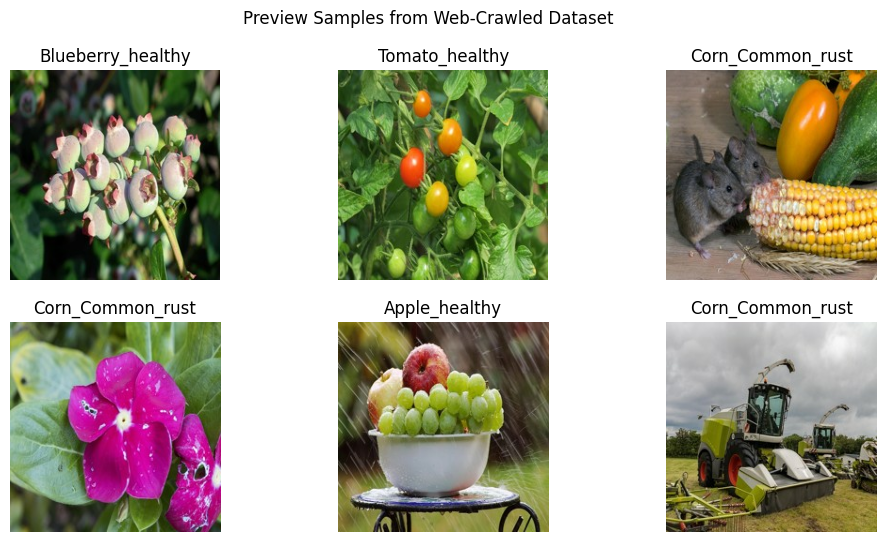

In [11]:
print("\nPlotting dataset preview figure...")
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(min(6, len(images))):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        class_idx = tf.argmax(labels[i]).numpy()
        plt.title(train_ds.class_names[class_idx])
        plt.axis('off')
plt.suptitle("Preview Samples from Web-Crawled Dataset")
plt.show()

In [12]:
zip_filename = 'final_plantvillage_dataset.zip'
print(f"\nCreating archival archive: '{zip_filename}'...")

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            zipf.write(os.path.join(root, file))

print(f"🎉 Process completed successfully! Dataset zipped as '{zip_filename}'")


Creating archival archive: 'final_plantvillage_dataset.zip'...
🎉 Process completed successfully! Dataset zipped as 'final_plantvillage_dataset.zip'
